## KDSS using Modified UNet

## 1. Setup

In [1]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
from sklearn.model_selection import KFold
from PIL import Image
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
for gpu in tf.config.list_physical_devices("GPU"):
    print(" ", gpu)

TensorFlow: 2.20.0
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


## 2. GPU Configuration

In [2]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy(["/GPU:0", "/GPU:1"])
else:
    strategy = tf.distribute.get_strategy()

print("Replicas:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Replicas: 2


I0000 00:00:1786952843.851773    5268 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786952843.854129    5268 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Hyperparameters

In [3]:
EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
N_FOLDS = 5
IMG_SIZE = 512
SEED = 42

## 4. Load Dataset

In [4]:
DATA_DIR = "/kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/data"
IMG_DIR = os.path.join(DATA_DIR, "image")
LABEL_DIR = os.path.join(DATA_DIR, "label")

image_files = sorted(os.listdir(IMG_DIR))
label_files = sorted(os.listdir(LABEL_DIR))
common = sorted(set(image_files) & set(label_files))
print(f"Matched pairs: {len(common)}")

X_list, Y_list = [], []
for fname in common:
    img = np.asarray(Image.open(os.path.join(IMG_DIR, fname)).convert("L"), dtype=np.float32) / 255.0
    msk = (np.asarray(Image.open(os.path.join(LABEL_DIR, fname)).convert("L"), dtype=np.float32) > 0).astype(np.float32)
    X_list.append(img[..., np.newaxis])
    Y_list.append(msk[..., np.newaxis])

X = np.array(X_list, dtype=np.float32)
Y = np.array(Y_list, dtype=np.float32)
del X_list, Y_list
gc.collect()

print(f"X: {X.shape}, Y: {Y.shape}")
print(f"X range: [{X.min():.1f}, {X.max():.1f}], Y unique: {np.unique(Y)}")

Matched pairs: 838
X: (838, 512, 512, 1), Y: (838, 512, 512, 1)
X range: [0.0, 1.0], Y unique: [0. 1.]


## 5. Dice Loss & Metrics

In [ ]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    """Per-sample dice loss â€” works correctly with MirroredStrategy."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    dice = (2.0 * intersection + smooth) / (denom + smooth)
    return 1.0 - dice  # shape: (batch,) Keras handles reduction

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))

def precision_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    pp = tf.reduce_sum(y_pred_bin, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (pp + smooth))

def recall_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    ap = tf.reduce_sum(y_true, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (ap + smooth))

## 6. Modified U-Net Architecture

From the paper:
- Encoder: 4 blocks with filters [16, 32, 64, 128], each has 2x(Conv3x3 + BN + ReLU) + dropout + MaxPool
- Bottleneck: 256 filters, 2x(Conv3x3 + BN + ReLU) + dropout
- Decoder: 4 blocks with Conv2DTranspose upsampling + skip concat + 2x(Conv3x3 + BN + ReLU)
- Dropout rates: 0.1, 0.2, 0.3, 0.3 (encoder blocks 1-4), 0.3 (bottleneck)
- Output: Conv2D 1x1 with sigmoid

In [ ]:
def conv_block(x, filters, dropout_rate=0.0):
    """Two 3x3 conv layers with BN, ReLU, and optional dropout after first conv."""
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_modified_unet(input_shape=(512, 512, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    e1 = conv_block(inputs, 16, dropout_rate=0.1)
    p1 = layers.MaxPooling2D(2)(e1)

    e2 = conv_block(p1, 32, dropout_rate=0.2)
    p2 = layers.MaxPooling2D(2)(e2)

    e3 = conv_block(p2, 64, dropout_rate=0.3)
    p3 = layers.MaxPooling2D(2)(e3)

    e4 = conv_block(p3, 128, dropout_rate=0.3)
    p4 = layers.MaxPooling2D(2)(e4)

    b = conv_block(p4, 256, dropout_rate=0.3)

    # Decoder
    u4 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(b)
    u4 = layers.Concatenate()([u4, e4])
    u4 = conv_block(u4, 128)

    u3 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(u4)
    u3 = layers.Concatenate()([u3, e3])
    u3 = conv_block(u3, 64)

    u2 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(u3)
    u2 = layers.Concatenate()([u2, e2])
    u2 = conv_block(u2, 32)

    u1 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(u2)
    u1 = layers.Concatenate()([u1, e1])
    u1 = conv_block(u1, 16)

    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(u1)

    return Model(inputs, outputs, name="Modified_UNet")

with strategy.scope():
    test_model = build_modified_unet()
print(f"Modified U-Net: {test_model.count_params():,} parameters")
print(f"Input: {test_model.input_shape}, Output: {test_model.output_shape}")
del test_model
tf.keras.backend.clear_session()

Modified U-Net: 1,945,233 parameters
Input: (None, 512, 512, 1), Output: (None, 512, 512, 1)


## 7. Creating 5 Folds for Cross Validation

In [7]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(kf.split(X))

for i, (tr, va) in enumerate(folds, 1):
    print(f"Fold {i}: train={len(tr)}, val={len(va)}")

Fold 1: train=670, val=168
Fold 2: train=670, val=168
Fold 3: train=670, val=168
Fold 4: train=671, val=167
Fold 5: train=671, val=167


## 8. Training Loop One Fold at a Time

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
all_histories = {}

for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*60}")

    train_ds = tf.data.Dataset.from_tensor_slices((X[train_idx], Y[train_idx]))
    train_ds = train_ds.shuffle(len(train_idx), reshuffle_each_iteration=True)
    train_ds = train_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X[val_idx], Y[val_idx]))
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    with strategy.scope():
        model = build_modified_unet()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss=dice_loss,
            metrics=[dice_coef, iou_metric, precision_metric, recall_metric],
        )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
    )

    all_histories[fold_idx] = history.history

    model.save(f"/kaggle/working/modified_unet_fold{fold_idx}.keras")
    print(f"Fold {fold_idx} saved.")

    del model, train_ds, val_ds
    tf.keras.backend.clear_session()
    gc.collect()


FOLD 1/5
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tenso

E0000 00:00:1786952871.375456    5268 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Modified_UNet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 345ms/step - dice_coef: 0.0104 - iou_metric: 0.0053 - loss: 0.9896 - precision_metric: 0.0292 - recall_metric: 0.9125 - val_dice_coef: 0.0032 - val_iou_metric: 0.0016 - val_loss: 0.9968 - val_precision_metric: 1.0000 - val_recall_metric: 4.4966e-09
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 315ms/step - dice_coef: 0.0307 - iou_metric: 0.0158 - loss: 0.9693 - precision_metric: 0.0967 - recall_metric: 0.8271 - val_dice_coef: 0.0013 - val_iou_metric: 6.7479e-04 - val_loss: 0.9987 - val_precision_metric: 5.0987e-04 - val_recall_metric: 0.0189
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 312ms/step - dice_coef: 0.1589 - iou_metric: 0.0917 - loss: 0.8411 - precision_metric: 0.3055 - recall_metric: 0.7072 - val_dice_coef: 0.0021 - val_iou_metric: 0.0011 - val_loss: 0.9979 - val_precision_metric: 0.0010 - val_recall_metric: 0.2150
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 314ms/step - dice_coef: 0.4123 - iou_metric: 0.2768 - loss: 0.5877 - precision_metric: 0.4703 - 

E0000 00:00:1786953173.120549    5268 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Modified_UNet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 335ms/step - dice_coef: 0.0092 - iou_metric: 0.0047 - loss: 0.9908 - precision_metric: 0.0206 - recall_metric: 0.9415 - val_dice_coef: 0.0051 - val_iou_metric: 0.0026 - val_loss: 0.9949 - val_precision_metric: 0.8048 - val_recall_metric: 1.1403e-04
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 321ms/step - dice_coef: 0.0212 - iou_metric: 0.0108 - loss: 0.9788 - precision_metric: 0.0856 - recall_metric: 0.8626 - val_dice_coef: 0.0029 - val_iou_metric: 0.0015 - val_loss: 0.9971 - val_precision_metric: 0.0014 - val_recall_metric: 0.6186
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 309ms/step - dice_coef: 0.0850 - iou_metric: 0.0461 - loss: 0.9150 - precision_metric: 0.2387 - recall_metric: 0.7602 - val_dice_coef: 0.0056 - val_iou_metric: 0.0028 - val_loss: 0.9944 - val_precision_metric: 0.0517 - val_recall_metric: 0.0251
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 312ms/step - dice_coef: 0.3334 - iou_metric: 0.2139 - loss: 0.6666 - precision_metric: 0.4531 - recall_m

...

83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 339ms/step - dice_coef: 0.0076 - iou_metric: 0.0038 - loss: 0.9924 - precision_metric: 0.0200 - recall_metric: 0.9266 - val_dice_coef: 0.0030 - val_iou_metric: 0.0015 - val_loss: 0.9970 - val_precision_metric: 1.0000 - val_recall_metric: 4.3722e-09
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 321ms/step - dice_coef: 0.0151 - iou_metric: 0.0076 - loss: 0.9849 - precision_metric: 0.0626 - recall_metric: 0.8829 - val_dice_coef: 0.0031 - val_iou_metric: 0.0016 - val_loss: 0.9969 - val_precision_metric: 0.0016 - val_recall_metric: 0.9802
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 307ms/step - dice_coef: 0.0420 - iou_metric: 0.0218 - loss: 0.9580 - precision_metric: 0.1675 - recall_metric: 0.7944 - val_dice_coef: 0.0051 - val_iou_metric: 0.0025 - val_loss: 0.9949 - val_precision_metric: 0.0066 - val_recall_metric: 0.0240
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 313ms/step - dice_coef: 0.1712 - iou_metric: 0.0994 - loss: 0.8288 - precision_metric: 0.3373 - recall_m

E0000 00:00:1786953759.965256    5268 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Modified_UNet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


83/83 ━━━━━━━━━━━━━━━━━━━━ 40s 361ms/step - dice_coef: 0.0092 - iou_metric: 0.0046 - loss: 0.9908 - precision_metric: 0.0220 - recall_metric: 0.9209 - val_dice_coef: 0.0027 - val_iou_metric: 0.0013 - val_loss: 0.9973 - val_precision_metric: 1.0000 - val_recall_metric: 4.3471e-09
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 313ms/step - dice_coef: 0.0206 - iou_metric: 0.0105 - loss: 0.9794 - precision_metric: 0.0858 - recall_metric: 0.8450 - val_dice_coef: 0.0027 - val_iou_metric: 0.0014 - val_loss: 0.9973 - val_precision_metric: 1.0000 - val_recall_metric: 4.3471e-09
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 310ms/step - dice_coef: 0.0747 - iou_metric: 0.0402 - loss: 0.9253 - precision_metric: 0.2294 - recall_metric: 0.7602 - val_dice_coef: 0.0037 - val_iou_metric: 0.0018 - val_loss: 0.9963 - val_precision_metric: 1.0000 - val_recall_metric: 4.3471e-09
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 312ms/step - dice_coef: 0.2910 - iou_metric: 0.1829 - loss: 0.7090 - precision_metric: 0.4385 - 

E0000 00:00:1786954054.281451    5268 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Modified_UNet_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - dice_coef: 0.0076 - iou_metric: 0.0038 - loss: 0.9924 - precision_metric: 0.0172 - recall_metric: 0.9608 - val_dice_coef: 0.0017 - val_iou_metric: 8.6339e-04 - val_loss: 0.9983 - val_precision_metric: 4.3645e-04 - val_recall_metric: 0.3456
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 319ms/step - dice_coef: 0.0151 - iou_metric: 0.0076 - loss: 0.9849 - precision_metric: 0.0669 - recall_metric: 0.8848 - val_dice_coef: 0.0032 - val_iou_metric: 0.0016 - val_loss: 0.9968 - val_precision_metric: 1.0000 - val_recall_metric: 4.0961e-09
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 308ms/step - dice_coef: 0.0445 - iou_metric: 0.0232 - loss: 0.9555 - precision_metric: 0.1626 - recall_metric: 0.8050 - val_dice_coef: 0.0032 - val_iou_metric: 0.0016 - val_loss: 0.9968 - val_precision_metric: 0.5368 - val_recall_metric: 0.0017
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 27s 316ms/step - dice_coef: 0.1991 - iou_metric: 0.1188 - loss: 0.8009 - precision_metric: 0.3537 - 

## 9. Results Summary

In [12]:
print(f"\n{'='*60}")
print("5-FOLD CV RESULTS Modified U-Net (10 Epochs)")
print(f"{'='*60}\n")

fold_dice = []
fold_iou = []
fold_prec = []
fold_rec = []

for fold_idx in range(1, N_FOLDS + 1):
    h = all_histories[fold_idx]
    best_dice = max(h["val_dice_coef"])
    best_iou = max(h["val_iou_metric"])
    best_prec = max(h["val_precision_metric"])
    best_rec = max(h["val_recall_metric"])

    fold_dice.append(best_dice)
    fold_iou.append(best_iou)
    fold_prec.append(best_prec)
    fold_rec.append(best_rec)

    print(f"Fold {fold_idx}: Dice={best_dice:.4f}  IoU={best_iou:.4f}  Prec={best_prec:.4f}  Recall={best_rec:.4f}")

print(f"\nMeanÂ±Std:")
print(f"  Dice:      {np.mean(fold_dice):.4f} Â± {np.std(fold_dice):.4f}")
print(f"  IoU:       {np.mean(fold_iou):.4f} Â± {np.std(fold_iou):.4f}")
print(f"  Precision: {np.mean(fold_prec):.4f} Â± {np.std(fold_prec):.4f}")
print(f"  Recall:    {np.mean(fold_rec):.4f} Â± {np.std(fold_rec):.4f}")


5-FOLD CV RESULTS Modified U-Net (10 Epochs)

Fold 1: Dice=0.5952  IoU=0.4427  Prec=1.0000  Recall=0.7001
Fold 2: Dice=0.5953  IoU=0.4402  Prec=0.8048  Recall=0.6985
Fold 3: Dice=0.5675  IoU=0.4150  Prec=1.0000  Recall=0.9802
Fold 4: Dice=0.5721  IoU=0.4162  Prec=1.0000  Recall=0.6762
Fold 5: Dice=0.5697  IoU=0.4139  Prec=1.0000  Recall=0.6305

MeanÂ±Std:
  Dice:      0.5799 Â± 0.0126
  IoU:       0.4256 Â± 0.0130
  Precision: 0.9610 Â± 0.0781
  Recall:    0.7371 Â± 0.1241


## 10. Training Curves

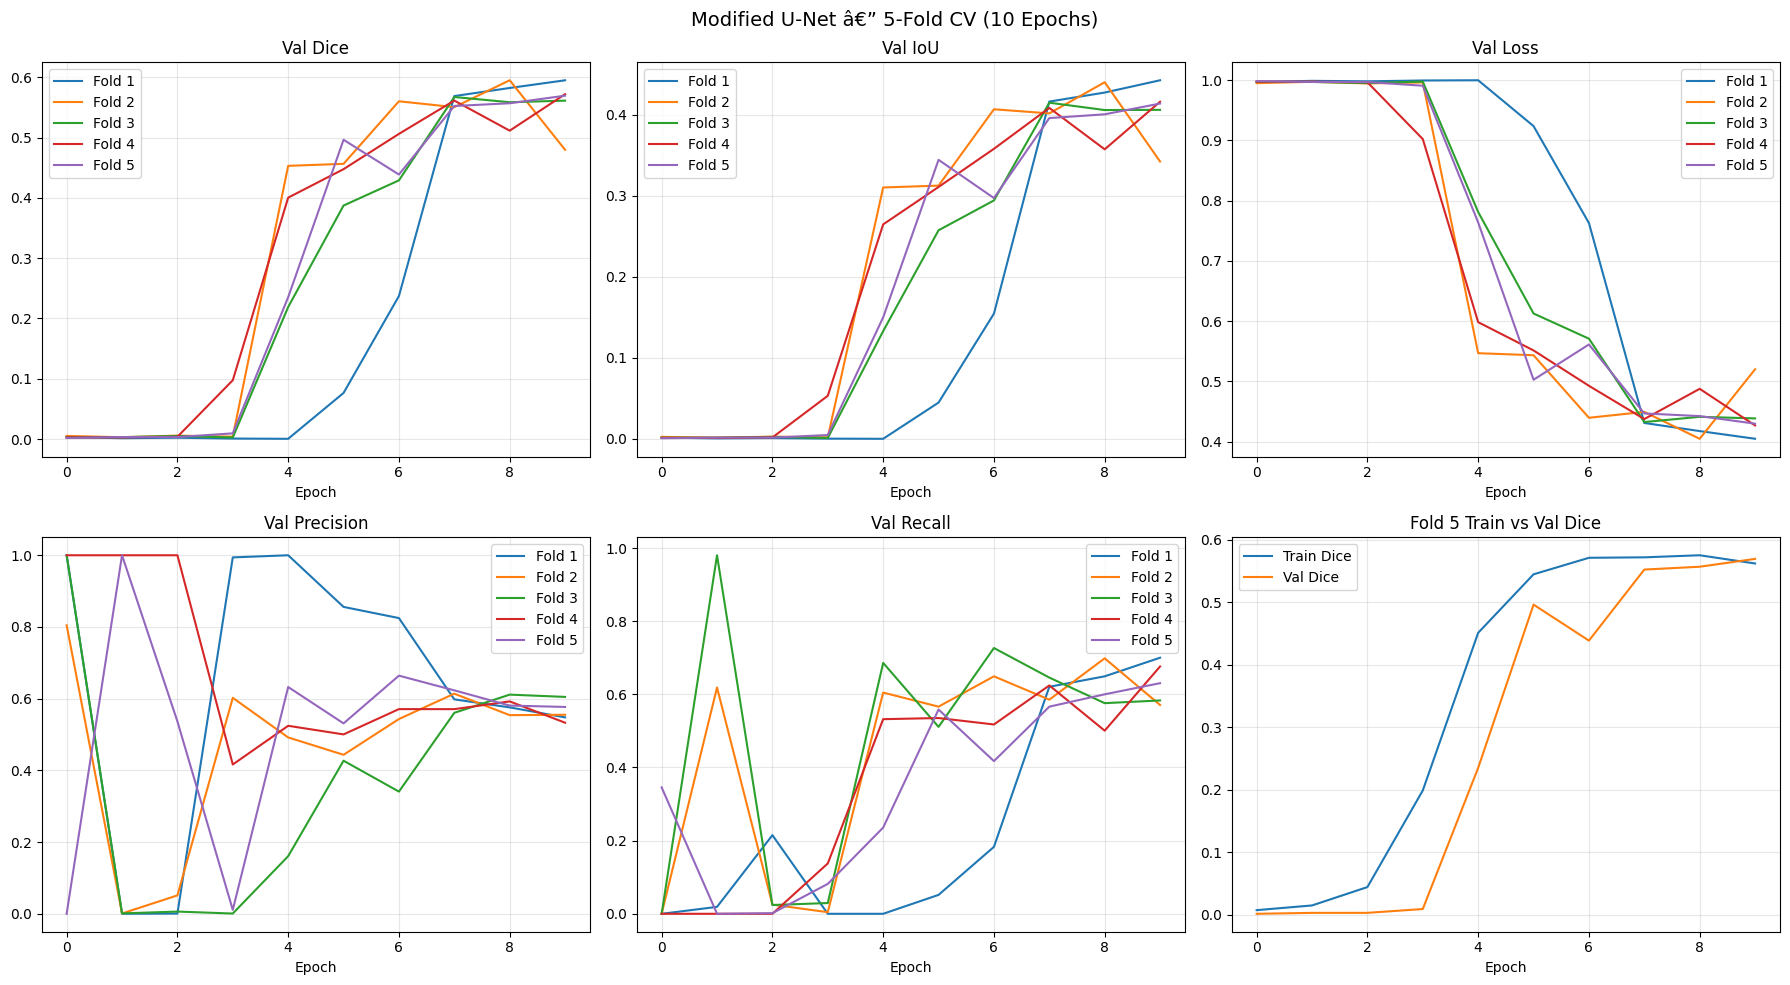

Saved: /kaggle/working/training_curves.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for fold_idx in range(1, N_FOLDS + 1):
    h = all_histories[fold_idx]

    # Dice
    axes[0, 0].plot(h["val_dice_coef"], label=f"Fold {fold_idx}")
    # IoU
    axes[0, 1].plot(h["val_iou_metric"], label=f"Fold {fold_idx}")
    # Loss
    axes[0, 2].plot(h["val_loss"], label=f"Fold {fold_idx}")
    # Precision
    axes[1, 0].plot(h["val_precision_metric"], label=f"Fold {fold_idx}")
    # Recall
    axes[1, 1].plot(h["val_recall_metric"], label=f"Fold {fold_idx}")
    # Train vs Val Dice (last fold)
    if fold_idx == N_FOLDS:
        axes[1, 2].plot(h["dice_coef"], label="Train Dice")
        axes[1, 2].plot(h["val_dice_coef"], label="Val Dice")

titles = ["Val Dice", "Val IoU", "Val Loss", "Val Precision", "Val Recall", f"Fold {N_FOLDS} Train vs Val Dice"]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Modified U-Net â€” 5-Fold CV (10 Epochs)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /kaggle/working/training_curves.png")

## 11. Sample Predictions (Last Fold)

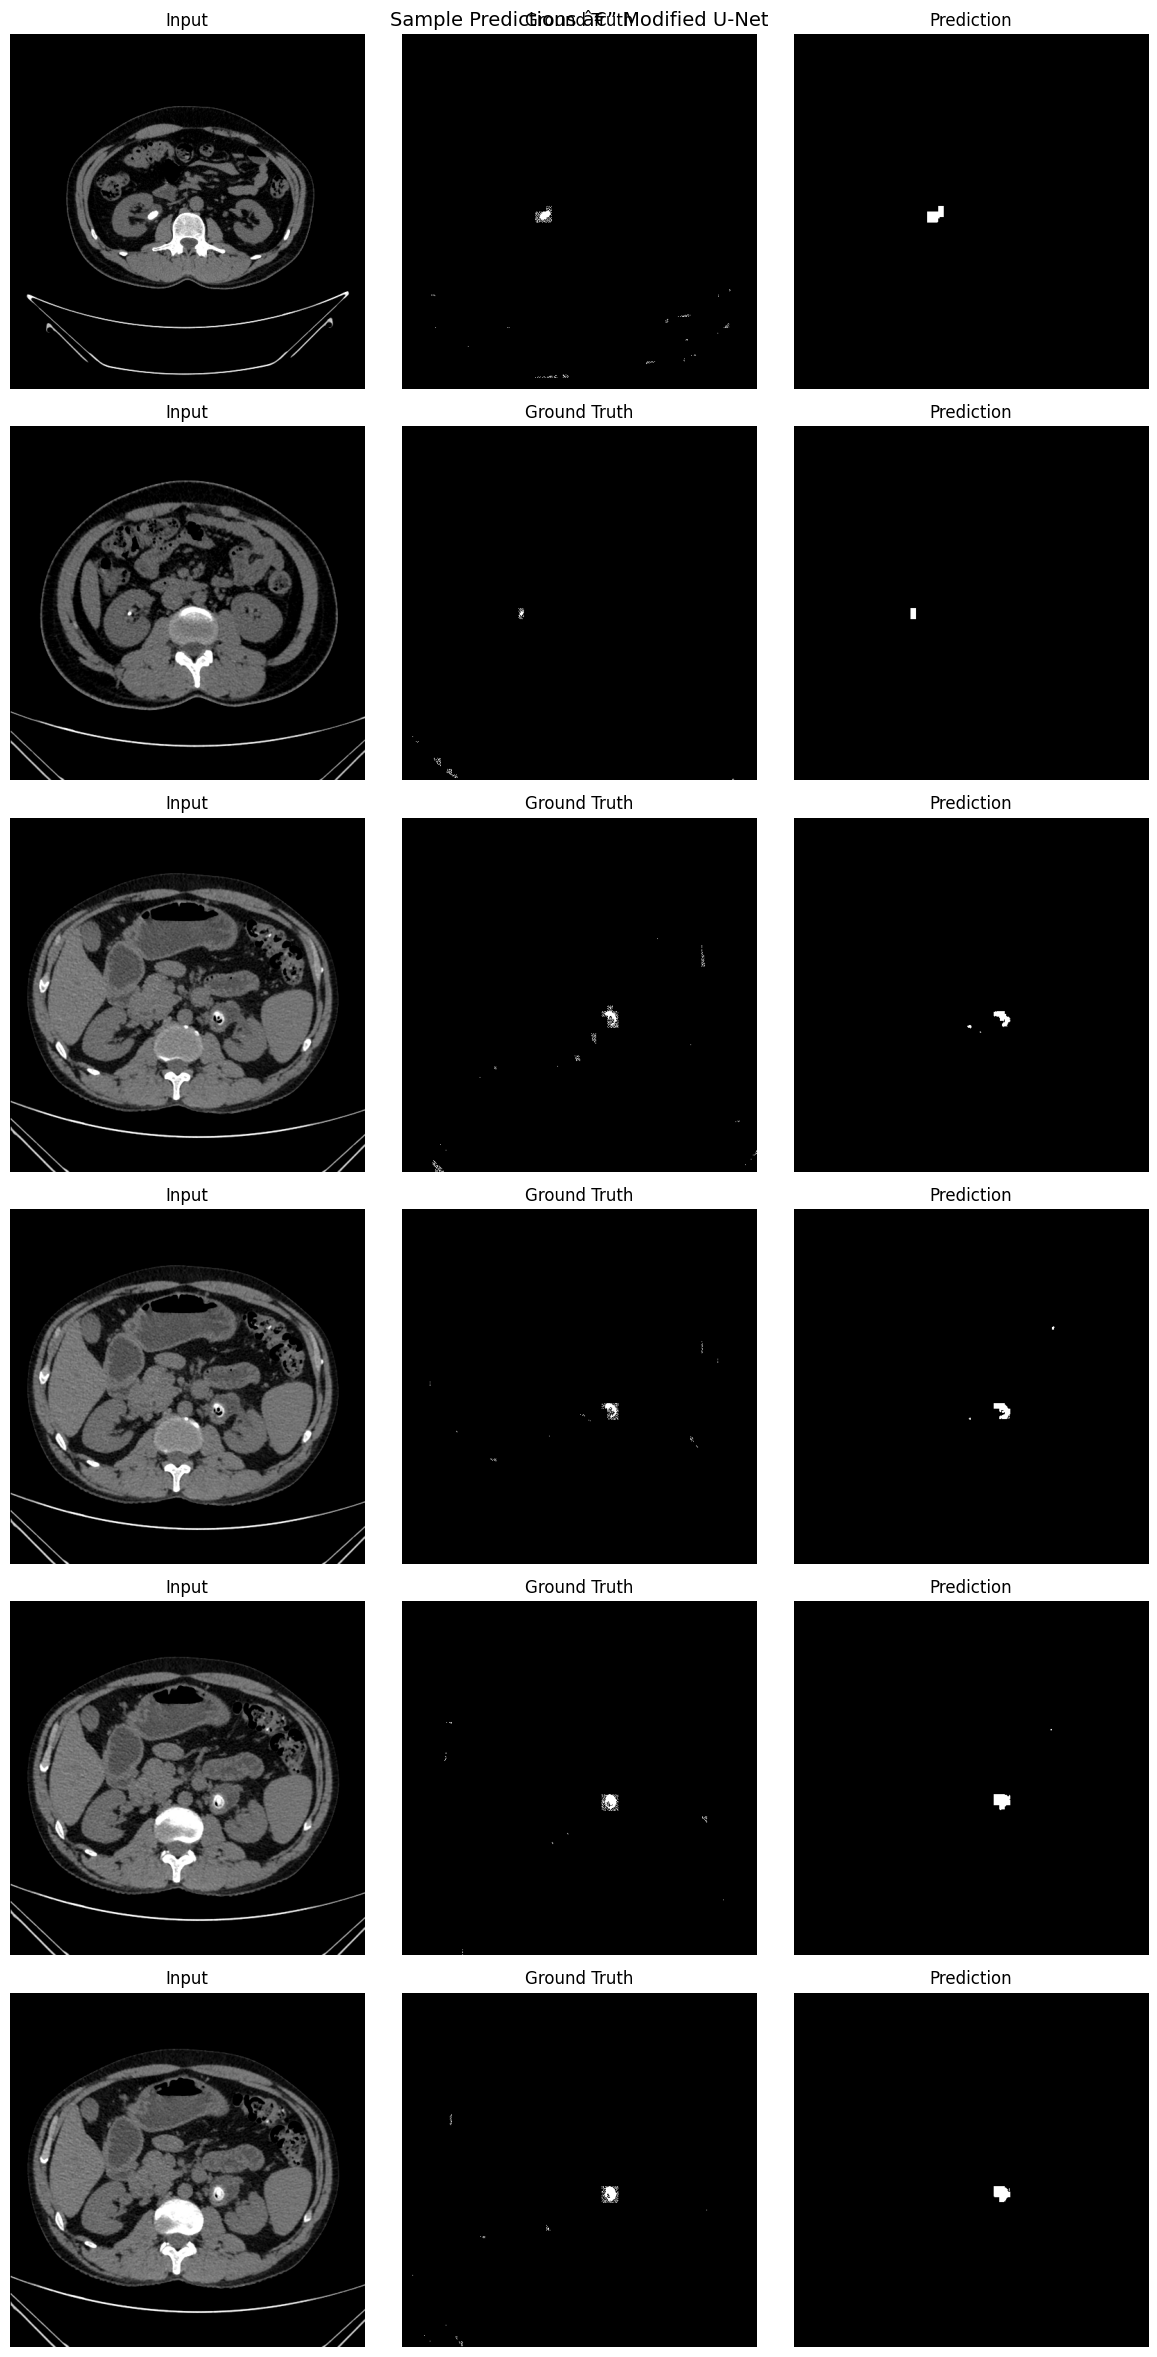

Done.


In [ ]:
last_model = tf.keras.models.load_model(
    f"/kaggle/working/modified_unet_fold{N_FOLDS}.keras",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coef": dice_coef,
        "iou_metric": iou_metric,
        "precision_metric": precision_metric,
        "recall_metric": recall_metric,
    },
)

_, last_val_idx = folds[N_FOLDS - 1]
sample_indices = last_val_idx[:6]

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
for i, idx in enumerate(sample_indices):
    img = X[idx]
    mask_true = Y[idx]
    mask_pred = last_model.predict(img[np.newaxis], verbose=0)[0]

    axes[i, 0].imshow(img[..., 0], cmap="gray")
    axes[i, 0].set_title("Input")
    axes[i, 1].imshow(mask_true[..., 0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(mask_pred[..., 0] > 0.5, cmap="gray")
    axes[i, 2].set_title("Prediction")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Sample Predictions â€” Modified U-Net", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

del last_model
gc.collect()
print("Done.")